In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
data = pd.read_csv("Advertising.csv")

In [3]:
print("Dataset Preview:")
print(data.head())

Dataset Preview:
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [4]:
print("\nMissing values:")
print(data.isnull().sum())


Missing values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [5]:
data = data.dropna()

In [6]:
X = data[['TV', 'Radio', 'Newspaper']]
y = data['Sales']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [9]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


Model Performance:
Mean Absolute Error: 1.4607567168117606
R2 Score: 0.899438024100912


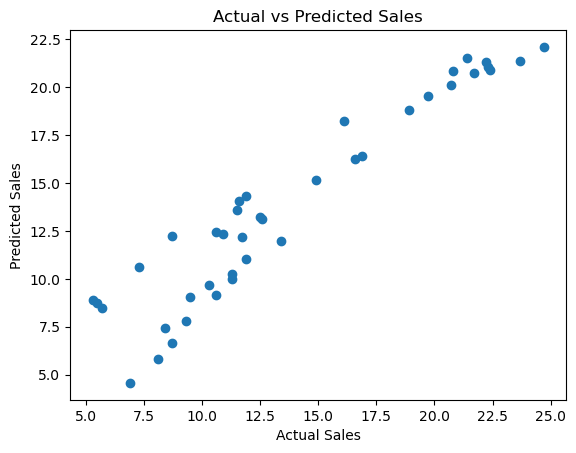

In [10]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [11]:
print("\nImpact of Advertising:")
for i, col in enumerate(X.columns):
    print(f"{col} Impact:", model.coef_[i])


Impact of Advertising:
TV Impact: 0.044729517468716326
Radio Impact: 0.1891950542343766
Newspaper Impact: 0.0027611143413671874


In [12]:
print("\nNew Sales Prediction Example:")
new_data = [[200, 50, 40]]
prediction = model.predict(new_data)
print("Predicted Sales:", prediction[0])


New Sales Prediction Example:
Predicted Sales: 21.49516811723941


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
